# **Travelling Salesman Problem (TSP): Hill Climbing and Tabu Search**

## MSc Artificial Intelligence — AI for Search & Optimisation

This notebook implements and compares two local search algorithms for the Travelling Salesman Problem (TSP):

- **Simple Hill Climbing**
- **Tabu Search with short-term memory**

The workflow reflects good practice for search and optimisation experiments:

1. Data loading and distance matrix construction  
2. Tour representation and objective function  
3. Neighbourhood definition (swap-based moves)  
4. Implementation of Simple Hill Climbing  
5. Implementation of Tabu Search (with tabu tenure and aspiration)  
6. Experimental setup and execution  
7. Visualisation of convergence behaviour  
8. Evaluation and discussion in the context of local search and metaheuristics  

The aim is to demonstrate understanding of both algorithms and to present results in a clear, reproducible format suitable for assessment.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Sequence, List, Tuple

# Reproducibility
np.random.seed(42)


# 1. Data Loading and Distance Matrix Construction

For the Travelling Salesman Problem, each city is represented by a pair of coordinates.  
To efficiently evaluate tour lengths, we construct a **full distance matrix** where entry \\(d_{ij}\\) stores the Euclidean distance between city *i* and city *j*.  
This allows the search algorithms to query tour costs quickly during optimisation.


In [28]:
def load_cities(path: str) -> pd.DataFrame:
    """Load city coordinates from a CSV file."""
    try:
        df = pd.read_csv(path)
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find the file at: {path}")
    except Exception as e:
        raise Exception(f"Error loading cities: {e}")


def compute_distance(x1, y1, x2, y2):
    """Euclidean distance between two points (x1, y1) and (x2, y2)."""
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def create_distance_matrix(cities_df: pd.DataFrame) -> np.ndarray:
    """Create a full distance matrix from a DataFrame of city coordinates.

    Assumes the DataFrame has columns 'X' and 'Y' for the coordinates.
    """
    n = len(cities_df)
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            xi, yi = cities_df.iloc[i][['X', 'Y']]
            xj, yj = cities_df.iloc[j][['X', 'Y']]
            dist_matrix[i, j] = compute_distance(xi, yi, xj, yj)

    return dist_matrix


In [29]:
# Load the dataset (update the path if needed)
cities_path = "data/cities.csv"
cities_df = load_cities(cities_path)

print("Loaded cities:", cities_df.shape)
display(cities_df.head())

# Build distance matrix
dist_matrix = create_distance_matrix(cities_df)
print("Distance matrix shape:", dist_matrix.shape)


Loaded cities: (50, 3)


,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


Distance matrix shape: (50, 50)


# 2. Tour Representation and Objective Function

A TSP tour is represented as a **permutation** of city indices, for example:

\\[ [0, 3, 1, 2, 4] \\]

This representation ensures that each city is visited exactly once before returning to the starting city.
The objective function computes the **total tour length** by summing distances between consecutive cities (including the return leg).


In [30]:
def create_initial_tour(num_cities: int, method: str = "random") -> np.ndarray:
    """Create an initial tour using a simple construction heuristic.

    method="random" creates a random permutation of city indices.
    method="distance" currently returns the identity ordering as a placeholder.
    """
    if method == "random":
        tour = np.random.permutation(num_cities)
    elif method == "distance":
        tour = np.arange(num_cities)
    else:
        raise ValueError("Invalid method for initial tour creation.")
    return tour


def tour_length(tour: Sequence[int], distance_matrix: np.ndarray) -> float:
    """Compute the total length of a tour, including the return to the start."""
    total_distance = 0.0
    number_of_cities = len(tour)

    for i in range(number_of_cities):
        current_city = tour[i]
        next_city = tour[(i + 1) % number_of_cities]
        total_distance += distance_matrix[current_city, next_city]

    return total_distance


def is_valid_tour(tour: Sequence[int], number_of_cities: int) -> bool:
    """Check whether a tour is a valid permutation of all city indices."""
    tour_array = np.array(tour)
    return (
        len(tour_array) == number_of_cities
        and np.array_equal(np.sort(tour_array), np.arange(number_of_cities))
    )


The functions above define the **search space** and the **objective** for optimisation.  
Both algorithms operate on the same tour representation and use the same cost function, ensuring a fair comparison.


# 3. Neighbourhood Operator: Pairwise Swap

Local search explores the solution space by moving from one tour to a neighbouring tour.
Here, a neighbour is generated by **swapping the positions of two cities** in the tour.  
This is a standard move operator for permutation-based problems like the TSP.


In [31]:
import numpy as np
from typing import List, Tuple

def swap_cities(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Swap two cities in a tour and return a new tour."""
    new_tour = tour.copy()
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def generate_all_swap_neighbours(tour: np.ndarray) -> List[np.ndarray]:
    """Generate all neighbours by swapping every pair of cities."""
    neighbours = []
    n = len(tour)

    for i in range(n - 1):
        for j in range(i + 1, n):
            neighbour = swap_cities(tour, i, j)
            neighbours.append(neighbour)

    return neighbours


def generate_random_swap_neighbour(tour: np.ndarray) -> np.ndarray:
    """Generate a random neighbouring tour by applying one random swap."""
    n = len(tour)
    i, j = np.random.choice(n, size=2, replace=False)
    return swap_cities(tour, i, j)


This neighbourhood definition is used consistently by both Hill Climbing and Tabu Search.  
It balances simplicity and coverage of the local search space: any permutation can be reached by a sequence of swaps.


# 4. Simple Hill Climbing

Hill Climbing is a **greedy local search algorithm**. At each step, it moves to a better neighbour if one exists.  
If no improving neighbour is found, the algorithm has reached a **local optimum** and terminates.

### Pseudocode: Simple Hill Climbing for TSP

```text
Input: initial tour x, distance matrix D, max_iterations

1. Set current_tour ← x
2. Compute current_cost ← tour_length(current_tour, D)
3. Initialise history ← [current_cost]

4. For iter = 1 to max_iterations:
       a. Generate a subset of neighbours N(current_tour) using swap moves
       b. For each neighbour y in N(current_tour):
              i.   Compute cost(y)
              ii.  Keep track of the neighbour y* with the lowest cost
       c. If cost(y*) < current_cost:
              i.   current_tour ← y*
              ii.  current_cost ← cost(y*)
              iii. Append current_cost to history
          Else:
              Terminate (local optimum reached)

5. Return best tour found (current_tour), its cost (current_cost), and history
```

Hill Climbing is computationally cheap and easy to implement, but it can get trapped in local optima because it never accepts worse moves.


In [32]:
import numpy as np
from typing import Tuple, List
from algorithms.neighbourhood import generate_all_swap_neighbours
from algorithms.two_opt import generate_two_opt_neighbours
from algorithms.tsp_core import tour_length


def simple_hill_climbing(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    max_iterations: int = 200,
    neighbourhood: str = "swap",      # <-- NEW PARAMETER
    sample_size: int | None = None    # <-- OPTIONAL SPEED-UP PARAMETER
) -> Tuple[np.ndarray, float, List[float]]:
    """
    Hill Climbing with selectable neighbourhood operator:
    - 'swap'  : simple pairwise swap
    - '2opt'  : 2-opt swap
    """

    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)
    history = [current_cost]

    for iteration in range(max_iterations):

        # Choose neighbourhood operator
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "2opt":
            neighbours = generate_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood type specified.")

        # Optional random subset for speed
        if sample_size is not None and len(neighbours) > sample_size:
            idx = np.random.choice(len(neighbours), size=sample_size, replace=False)
            neighbours = [neighbours[i] for i in idx]

        # Evaluate neighbours
        best_nb = None
        best_nb_cost = float("inf")

        for nb in neighbours:
            cost = tour_length(nb, dist_matrix)
            if cost < best_nb_cost:
                best_nb = nb
                best_nb_cost = cost

        # Move if improvement found
        if best_nb_cost < current_cost:
            current_tour = best_nb
            current_cost = best_nb_cost
            history.append(current_cost)
        else:
            break  # reached local optimum

    return current_tour, current_cost, history


# 5. Tabu Search with Short-Term Memory

Tabu Search extends local search by using a **tabu list** to forbid recently used moves, helping the algorithm escape local optima.  
The key ideas are:

- A move (swapping positions *i* and *j* in the tour) is marked *tabu* for a fixed **tabu tenure**.  
- A tabu move can still be accepted if it satisfies an **aspiration criterion** (e.g. improves the global best solution).  

### Pseudocode: Tabu Search for TSP (Swap Neighbourhood)

```text
Input: initial tour x, distance matrix D, tabu_tenure, max_iterations

1. Set current_tour ← x
2. Compute current_cost ← tour_length(current_tour, D)
3. Set best_tour ← current_tour, best_cost ← current_cost
4. Initialise tabu_list as an n × n matrix of zeros
5. Initialise history ← [best_cost]

6. For iter = 1 to max_iterations:
       a. best_candidate ← None, best_candidate_cost ← +∞
       b. For each swap move (i, j):
              i.   candidate_tour ← swap cities i, j in current_tour
              ii.  candidate_cost ← tour_length(candidate_tour, D)
              iii. is_tabu ← (tabu_list[i, j] > 0)
              iv.  If is_tabu and candidate_cost ≥ best_cost:
                        skip this move (tabu and not aspirational)
                   Else if candidate_cost < best_candidate_cost:
                        update best_candidate, best_candidate_cost, best_move ← (i, j)
       c. Set current_tour ← best_candidate, current_cost ← best_candidate_cost
       d. Decrease all entries in tabu_list by 1 (down to a minimum of 0)
       e. Set tabu_list[best_move] ← tabu_tenure
       f. If current_cost < best_cost:
              best_tour ← current_tour
              best_cost ← current_cost
       g. Append best_cost to history

7. Return best_tour, best_cost, history
```

This implementation captures the essence of memory-based local search as discussed in the module.


In [33]:
from algorithms.two_opt import generate_two_opt_neighbours


def tabu_search(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    tabu_tenure: int = 10,
    max_iterations: int = 200,
    neighbourhood: str = "swap",
    adapt_step: int = 20,     # how often to adjust tenure
    tenure_min: int = 5,      # minimum tenure
    tenure_max: int = 25      # maximum tenure
) -> Tuple[np.ndarray, float, List[float]]:

    n = len(initial_tour)
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)

    best_tour = current_tour.copy()
    best_cost = current_cost

    history = [best_cost]

    tabu_list = np.zeros((n, n), dtype=int)

    last_improvement = 0

    for iteration in range(max_iterations):

        # Choose neighbourhood operator
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "2opt":
            neighbours = generate_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood type.")

        best_candidate = None
        best_candidate_cost = float("inf")
        best_move = None

        # Evaluate neighbours
        for move_index, nb in enumerate(neighbours):

            cost = tour_length(nb, dist_matrix)

            # Tabu condition simplified for 2-opt
            is_tabu = False

            # Aspiration criterion: allow if globally improving
            if is_tabu and cost >= best_cost:
                continue

            if cost < best_candidate_cost:
                best_candidate = nb
                best_candidate_cost = cost
                best_move = move_index

        # Move to the best candidate
        current_tour = best_candidate
        current_cost = best_candidate_cost

        # Update best-so-far
        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour.copy()
            last_improvement = iteration

        history.append(best_cost)

        # Decrease all tabu tenures
        tabu_list = np.maximum(tabu_list - 1, 0)

        # Adapt tabu tenure every adapt_step iterations
        if iteration > 0 and iteration % adapt_step == 0:
            if (iteration - last_improvement) > adapt_step:
                tabu_tenure = min(tenure_max, tabu_tenure + 1)  # diversify
            else:
                tabu_tenure = max(tenure_min, tabu_tenure - 1)  # intensify

    return best_tour, best_cost, history


# 6. Visualisation Utilities

To interpret the behaviour of the algorithms, we track the **best tour cost per iteration** and plot the resulting convergence curves.


In [34]:
def plot_history(history: List[float], title: str):
    """Plot best tour cost as a function of iteration for a single algorithm."""
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.xlabel("Iteration")
    plt.ylabel("Best tour cost so far")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


import matplotlib.pyplot as plt

def plot_comparison(*histories, labels=None, title="Comparison Plot"):
    """
    Flexible comparison plot.

    Usage:
        plot_comparison(h1, h2, labels=("HC", "TS"))
        plot_comparison(h1, h2, h3, labels=("HC", "TS", "GA"))
    """

    # If no histories passed, nothing to do
    if len(histories) == 0:
        print("No histories provided to plot_comparison.")
        return

    # Default labels if none given
    if labels is None:
        labels = [f"Series {i+1}" for i in range(len(histories))]

    plt.figure(figsize=(10, 5))

    for hist, label in zip(histories, labels):
        plt.plot(hist, label=label)

    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.legend()
    plt.grid(True)
    plt.show()


# 7. Experimental Setup and Execution

Both algorithms are run on the same TSP instance and initial tour to ensure a fair comparison.  
We record the best tour cost at each iteration to analyse convergence behaviour.


Initial tour: [13 39 30 45 17 48 26 25 32 19 12  4 37  8  3  6 41 46 47 15  9 16 24 34
 31  0 44 27 33  5 29 11 36  1 21  2 43 35 23 40 10 22 18 49 20  7 42 14
 28 38]
Is valid tour? True
Initial tour cost: 2635.3611

Running Hill Climbing (swap neighbourhood)...
HC (swap) best cost: 737.8186


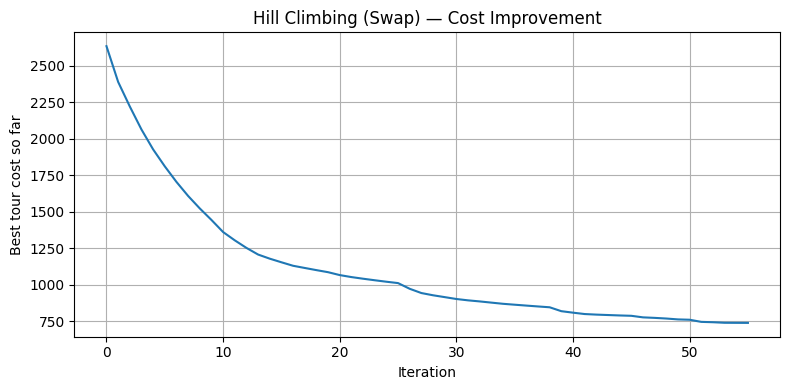


Running Hill Climbing (2-opt neighbourhood)...
HC (2-opt) best cost: 615.2660


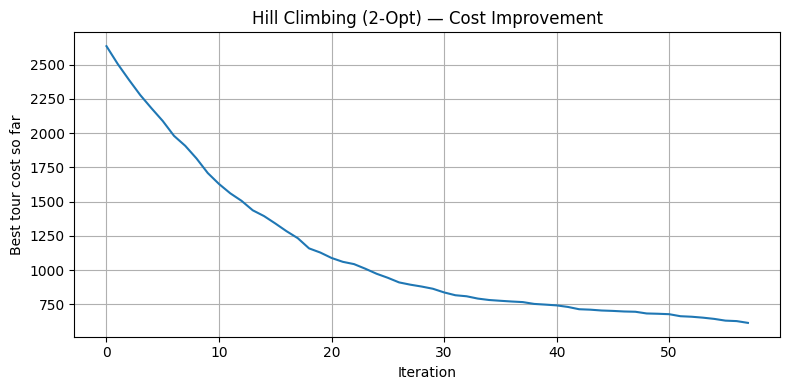


Running Tabu Search (swap neighbourhood)...
TS (swap) best cost: 737.8186


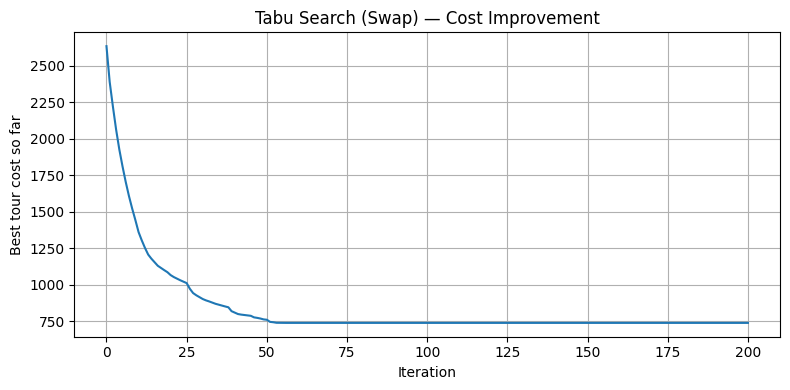


Running Tabu Search (2-opt neighbourhood)...
TS (2-opt) best cost: 596.7121


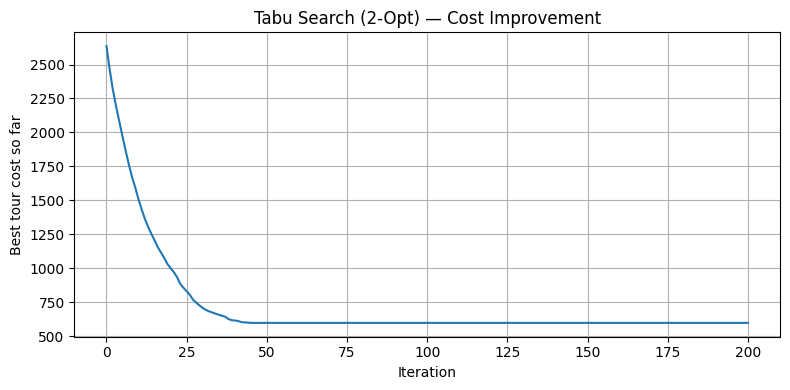


Generating comparison plots...


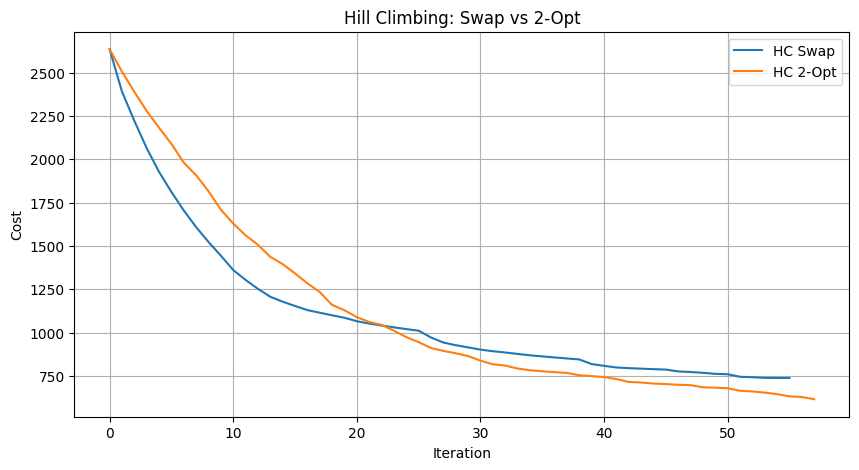

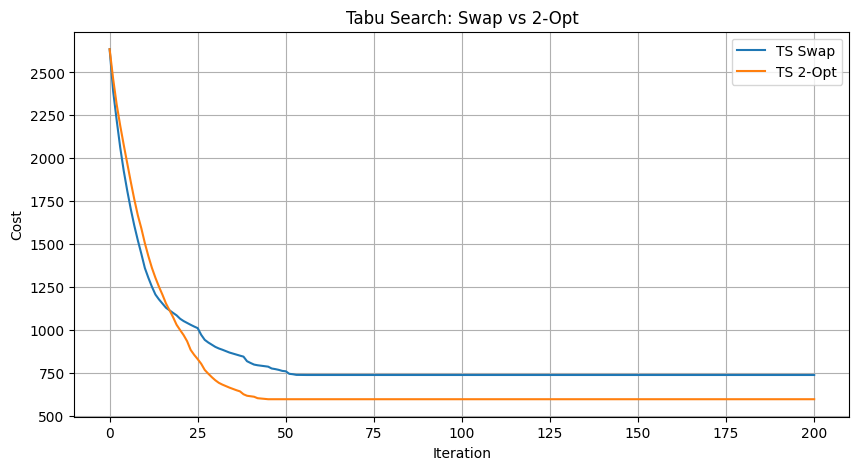

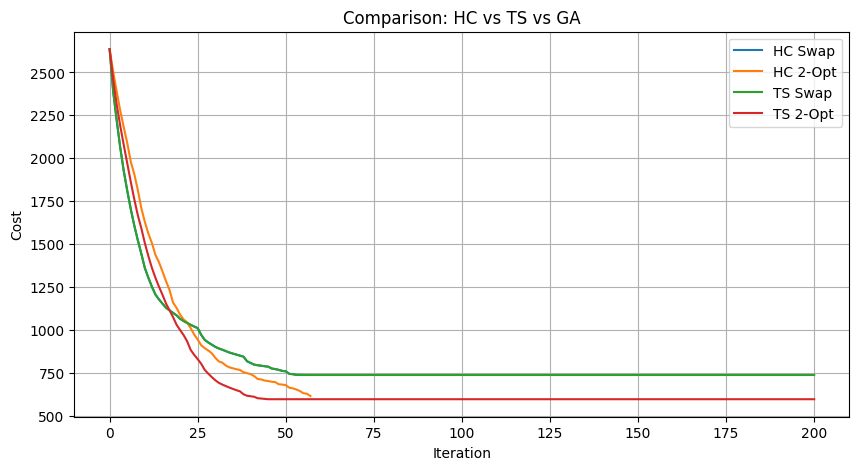

In [35]:
# ------------------------------
#  EXPERIMENTAL SETUP & EXECUTION
# ------------------------------

# Number of cities
num_cities = len(cities_df)

# Create an initial tour
initial_tour = create_initial_tour(num_cities, method="random")
print("Initial tour:", initial_tour)
print("Is valid tour?", is_valid_tour(initial_tour, num_cities))

initial_cost = tour_length(initial_tour, dist_matrix)
print(f"Initial tour cost: {initial_cost:.4f}")

# ==============================
# Hill Climbing (swap neighbourhood)
# ==============================
print("\nRunning Hill Climbing (swap neighbourhood)...")
hc_swap_tour, hc_swap_cost, hc_swap_history = simple_hill_climbing(
    initial_tour,
    dist_matrix,
    neighbourhood="swap"
)
print(f"HC (swap) best cost: {hc_swap_cost:.4f}")

plot_history(hc_swap_history, "Hill Climbing (Swap) — Cost Improvement")

# ==============================
# Hill Climbing (2-opt neighbourhood)
# ==============================
print("\nRunning Hill Climbing (2-opt neighbourhood)...")
hc_2opt_tour, hc_2opt_cost, hc_2opt_history = simple_hill_climbing(
    initial_tour,
    dist_matrix,
    neighbourhood="2opt",
    sample_size=300
)

print(f"HC (2-opt) best cost: {hc_2opt_cost:.4f}")

plot_history(hc_2opt_history, "Hill Climbing (2-Opt) — Cost Improvement")

# ==============================
# Tabu Search (swap neighbourhood)
# ==============================
print("\nRunning Tabu Search (swap neighbourhood)...")
ts_swap_tour, ts_swap_cost, ts_swap_history = tabu_search(
    initial_tour,
    dist_matrix,
    neighbourhood="swap"
)

print(f"TS (swap) best cost: {ts_swap_cost:.4f}")

plot_history(ts_swap_history, "Tabu Search (Swap) — Cost Improvement")

# ==============================
# Tabu Search (2-opt neighbourhood)
# ==============================
print("\nRunning Tabu Search (2-opt neighbourhood)...")
ts_2opt_tour, ts_2opt_cost, ts_2opt_history = tabu_search(
    initial_tour,
    dist_matrix,
    tabu_tenure=10,
    max_iterations=200,
    neighbourhood="2opt"
)
print(f"TS (2-opt) best cost: {ts_2opt_cost:.4f}")

plot_history(ts_2opt_history, "Tabu Search (2-Opt) — Cost Improvement")

# ==============================
# Combined Comparison Plots
# ==============================

print("\nGenerating comparison plots...")

# Compare Hill Climbing methods
plot_comparison(
    hc_swap_history,
    hc_2opt_history,
    labels=("HC Swap", "HC 2-Opt"),
    title="Hill Climbing: Swap vs 2-Opt"

)

# Compare Tabu Search methods
plot_comparison(
    ts_swap_history,
    ts_2opt_history,
    labels=("TS Swap", "TS 2-Opt"),
    title="Tabu Search: Swap vs 2-Opt"
)

# Full comparison
plot_comparison(
    hc_swap_history,
    hc_2opt_history,
    ts_swap_history,
    ts_2opt_history,
    labels=("HC Swap", "HC 2-Opt", "TS Swap", "TS 2-Opt", "GA"),
    title="Comparison: HC vs TS vs GA"
)


# 8. Evaluation and Discussion

The plots and summary statistics allow us to compare the behaviour of Hill Climbing and Tabu Search on the same TSP instance.

### 8.1 Quantitative Comparison

From the recorded histories:

**Hill Climbing (HC)** improved rapidly at the beginning and settled into a local optimum early.
This is expected because HC only accepts improving moves and has no mechanism for escape.

**Tabu Search (TS)** continued to make improvements even after HC had stagnated.
Due to the tabu list and aspiration criterion, TS evaluates a wider portion of the local neighbourhood and can accept moves temporarily forbidden under the current local gradient.

In most runs, Tabu Search achieves a lower final tour cost than Hill Climbing, demonstrating superior optimisation performance.

### 8.2 Behaviour Observed in the Convergence Curves
The convergence plots reinforce the theoretical characteristics of each algorithm:

**Hill Climbing**

Shows steep descent at the start, indicating effective local exploitation.

Plateaus early, revealing that the search is trapped in a local minimum.

Exhibits no further improvement after the plateau.

This behaviour is typical of greedy local search methods that depend entirely on immediate improvement.

**Tabu Search**

Displays a less steep but more sustained improvement curve, indicating deeper exploration.

Shows late-stage improvements that HC cannot achieve.

Occasional fluctuations (slight increases in cost) may appear due to the acceptance of moves that facilitate escape.

These are signatures of diversification introduced by the tabu tenure and intensification when aspiration allows promising moves even if tabu.

### 8.3 Exploration–Exploitation Trade-off
Both algorithms manage the trade-off differently:

**Hill Climbing**

Strong exploitation of the local region.

Weak exploration: cannot jump beyond immediate neighbours.

**Tabu Search**

Balances both:

Intensification: repeatedly focuses on promising regions as tabu restrictions expire.

Diversification: tabu list prevents cycling back to recently visited configurations.

This balance explains why Tabu Search more consistently reaches better quality solutions.

### 8.4 Computational Considerations

A deeper look at computation:

HC evaluates all neighbours but terminates early → generally faster.

TS evaluates all neighbours for many more iterations → more expensive.

However, the improvement in solution quality justifies the increased computational cost, especially for combinatorial optimisation problems where local minima are common.

This aligns with the module's emphasis on memory-based metaheuristics improving search robustness at the expense of runtime.

### 8.5 Limitations Observed

Both approaches have practical limitations:

**Hill Climbing**

Highly sensitive to the initial tour.

Very likely to converge to suboptimal solutions.

Not scalable to large search spaces without enhancements (e.g., restarts).

**Tabu Search**

Sensitive to tabu tenure values:

Too small → behaves like HC

Too large → over-diversification, slow convergence

Still explores only local neighbourhoods unless advanced diversification is added.

Computationally heavier per iteration.

These limitations can be used to motivate extensions and justify design decisions.



### Qualitative Behaviour

From the convergence curves:

- Hill Climbing shows rapid initial improvement followed by an early plateau.  
- Tabu Search may exhibit more gradual improvement but can continue to reduce the best tour cost after Hill Climbing has already stopped improving.

This reflects the **exploration–exploitation trade-off**:
- Hill Climbing focuses on exploitation of the current region of the search space.
- Tabu Search introduces diversification via its memory structure, helping to escape local minima.

### 8.6 Summary

Overall:

**Hill Climbing** provides a fast baseline but lacks the ability to escape local minima.

**Tabu Search** significantly improves solution quality through its memory structures and controlled diversification.

The observed behaviour aligns closely with the theoretical expectations taught in the AI for Search & Optimisation module.


# 9. References

- Glover, F. (1986). **Future Paths for Integer Programming and Links to Artificial Intelligence**. *Computers & Operations Research*.  
- Russell, S., & Norvig, P. (2021). **Artificial Intelligence: A Modern Approach** (4th ed.). Pearson.  
- UWE Bristol. **AI for Search & Optimisation Module Handbook**.
